# 📈 Nvidia Stock Price Trading Agent

We’re going to take a deep dive into NVIDIA’s stock price from 2010 all the way to today, uncovering the hidden trends buried in the data. To take things a step further, we’ll use unsupervised learning to engineer some fresh features.

The goal -> To feed all that intel into a reinforcement learning model and build a trading agent that can actually hold its own in the market.

Data can be found in the https://pypi.org/project/yfinance/ API. Details on how to extract will be in the README file

### Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import helper_functions as hf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")


import pandas as pd
import yfinance as yf
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.3f}'.format

In [2]:
# Inputs
START_DATE = "2010-01-01"
end_date = "2026-04-12"
TICKER = "NVDA"

In [3]:
ticker = yf.Ticker(TICKER)
df = ticker.history(start=START_DATE,auto_adjust=False)

df = (
    df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume"
    })
    .sort_index()
)



In [4]:
df.head()

,open,high,low,close,adj_close,volume,Dividends,Stock Splits
Date,,,,,,,,
2010-01-04 00:00:00-05:00,0.463,0.465,0.453,0.462,0.424,800204000,0.000,0.000
2010-01-05 00:00:00-05:00,0.461,0.474,0.461,0.469,0.430,728648000,0.000,0.000
2010-01-06 00:00:00-05:00,0.469,0.473,0.464,0.472,0.433,649168000,0.000,0.000
2010-01-07 00:00:00-05:00,0.470,0.472,0.459,0.463,0.424,547792000,0.000,0.000
2010-01-08 00:00:00-05:00,0.459,0.467,0.456,0.464,0.425,478168000,0.000,0.000


In [5]:

# Standard Fields
df["stock_splits"] = ticker.splits.reindex(df.index).fillna(0.0)
df["returns"] = np.log(df["adj_close"]).diff()
df["volatility_20d"] = df["returns"].rolling(20).std()
df["volume_zscore_20d"] = ((df["volume"] - df["volume"].rolling(20).mean())/ df["volume"].rolling(20).std())

# Trends
df["sma_20"] = df["adj_close"].rolling(20).mean()
df["sma_50"] = df["adj_close"].rolling(50).mean()
df["ema_20"] = df["adj_close"].ewm(span=20, adjust=False).mean()
df["momentum_10d"] = df["adj_close"].pct_change(10)
df["trend_strength"] = ((df["sma_20"] - df["sma_50"]) / df["sma_50"])

# Volatility
prev_close = df["close"].shift(1)
df["true_range"] = np.maximum.reduce([df["high"] - df["low"],(df["high"] - prev_close).abs(),(df["low"] - prev_close).abs()])
df["atr_14"] = df["true_range"].rolling(14).mean()
df["volatility_ratio"] = (df["volatility_20d"]/ df["volatility_20d"].rolling(60).mean())


# Risk
df["rolling_max_252d"] = df["adj_close"].rolling(252).max()
df["drawdown"] = df["adj_close"] / df["rolling_max_252d"] - 1
df["distance_from_high"] = df["drawdown"]  # alias (intentional)
df["is_split_day"] = (df["stock_splits"] > 0).astype(int)


df = df.dropna().reset_index().rename(columns={"Date": "date"})

df.head()


,date,open,high,low,close,adj_close,volume,Dividends,Stock Splits,stock_splits,returns,volatility_20d,volume_zscore_20d,sma_20,sma_50,ema_20,momentum_10d,trend_strength,true_range,atr_14,volatility_ratio,rolling_max_252d,drawdown,distance_from_high,is_split_day
0,2010-12-31 00:00:00-05:00,0.375,0.386,0.375,0.385,0.353,391252000,0.000,0.000,0.000,0.027,0.018,-0.468,0.339,0.312,0.336,0.078,0.087,0.011,0.009,0.840,0.433,-0.184,-0.184,0
1,2011-01-03 00:00:00-05:00,0.388,0.399,0.387,0.396,0.363,817448000,0.000,0.000,0.000,0.027,0.018,1.232,0.340,0.314,0.338,0.101,0.083,0.014,0.009,0.842,0.433,-0.162,-0.162,0
2,2011-01-04 00:00:00-05:00,0.396,0.398,0.386,0.394,0.361,651384000,0.000,0.000,0.000,-0.003,0.017,0.515,0.341,0.316,0.341,0.102,0.081,0.012,0.009,0.814,0.433,-0.165,-0.165,0
3,2011-01-05 00:00:00-05:00,0.401,0.425,0.398,0.424,0.389,1428216000,0.000,0.000,0.000,0.074,0.022,2.933,0.344,0.318,0.345,0.142,0.080,0.031,0.010,1.074,0.425,-0.085,-0.085,0
4,2011-01-06 00:00:00-05:00,0.435,0.484,0.434,0.483,0.443,3493312000,0.000,0.000,0.000,0.130,0.035,3.866,0.349,0.322,0.355,0.286,0.084,0.059,0.014,1.695,0.443,0.000,0.000,0


## Data Preparation

In [6]:
df.dtypes

date                  datetime64[ns, America/New_York]
open                                           float64
high                                           float64
low                                            float64
close                                          float64
adj_close                                      float64
volume                                           int64
Dividends                                      float64
Stock Splits                                   float64
stock_splits                                   float64
returns                                        float64
volatility_20d                                 float64
volume_zscore_20d                              float64
sma_20                                         float64
sma_50                                         float64
ema_20                                         float64
momentum_10d                                   float64
trend_strength                                 float64
true_range

In [7]:
df.describe()

,open,high,low,close,adj_close,volume,Dividends,Stock Splits,stock_splits,returns,volatility_20d,volume_zscore_20d,sma_20,sma_50,ema_20,momentum_10d,trend_strength,true_range,atr_14,volatility_ratio,rolling_max_252d,drawdown,distance_from_high,is_split_day
count,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000,3847.000
mean,27.271,27.718,26.776,27.267,27.234,456786029.288,0.000,0.004,0.004,0.002,0.026,-0.018,26.769,26.066,26.771,0.020,0.025,1.056,1.048,1.019,30.833,-0.144,-0.144,0.001
std,49.776,50.512,48.927,49.743,49.743,294561863.910,0.001,0.174,0.174,0.029,0.012,1.055,49.040,48.022,49.018,0.089,0.068,2.131,1.909,0.360,54.389,0.161,0.161,0.023
min,0.287,0.291,0.279,0.285,0.261,45644000.000,0.000,0.000,0.000,-0.208,0.006,-2.848,0.273,0.281,0.277,-0.323,-0.212,0.002,0.005,0.381,0.339,-0.663,-0.663,0.000
25%,0.499,0.504,0.491,0.499,0.478,270668350.000,0.000,0.000,0.000,-0.012,0.017,-0.708,0.479,0.467,0.479,-0.031,-0.012,0.015,0.016,0.785,0.589,-0.226,-0.226,0.000
50%,4.689,4.761,4.621,4.689,4.641,391720000.000,0.000,0.000,0.000,0.002,0.023,-0.272,4.576,4.406,4.555,0.017,0.023,0.138,0.147,0.958,6.293,-0.076,-0.076,0.000
75%,20.956,21.264,20.650,20.823,20.778,552959200.000,0.000,0.000,0.000,0.016,0.033,0.438,20.925,20.451,20.930,0.069,0.065,0.892,0.854,1.147,33.306,-0.021,-0.021,0.000
max,208.080,212.190,205.560,207.040,207.017,3692928000.000,0.010,10.000,10.000,0.261,0.088,4.072,193.373,187.287,192.680,0.563,0.278,25.920,9.459,3.477,207.017,0.000,0.000,1.000


Based on the describe there's a whole bunch of fields which aren't giving us any value. For example some fields pretty much have the same value split over every quartile, this won't help us much. But let's plot their distributions to double check we're not missing anything.

Skipping date: Non-numeric data


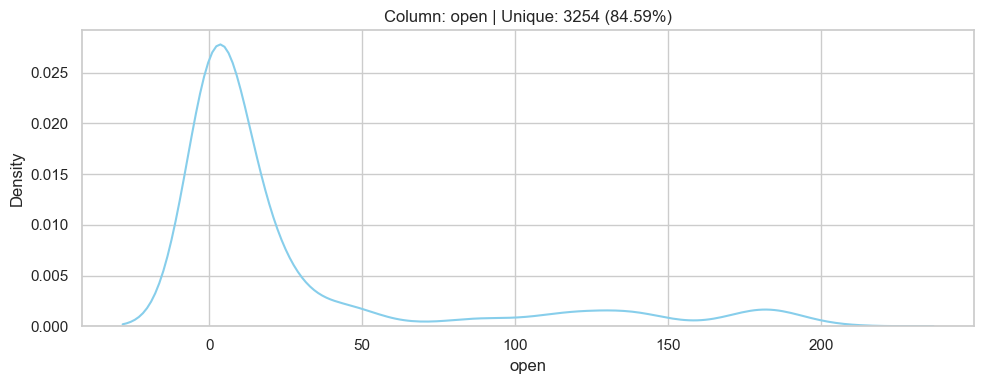

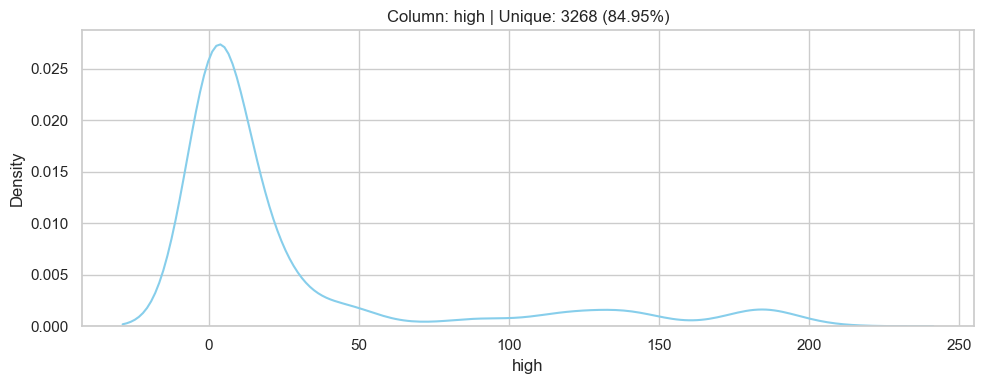

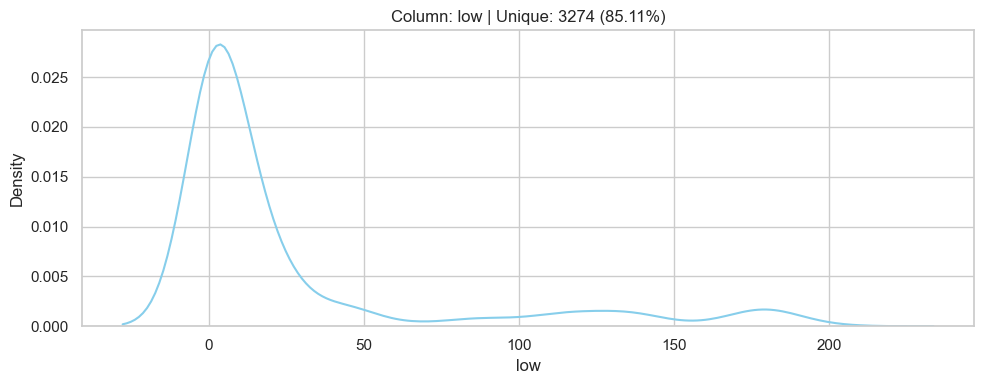

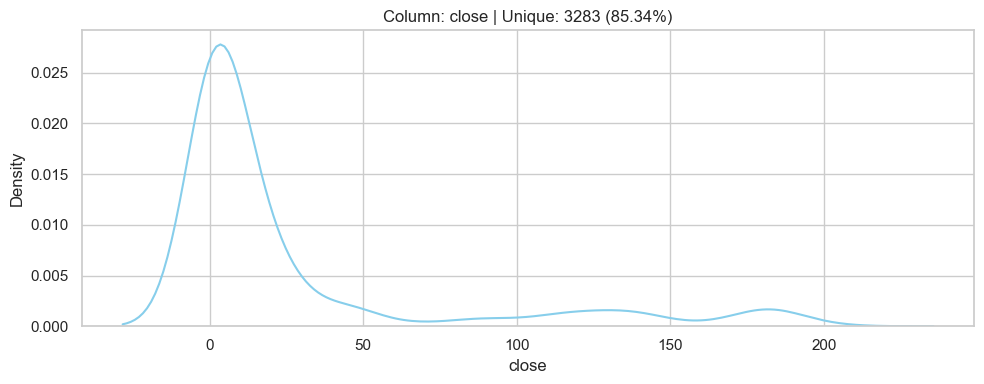

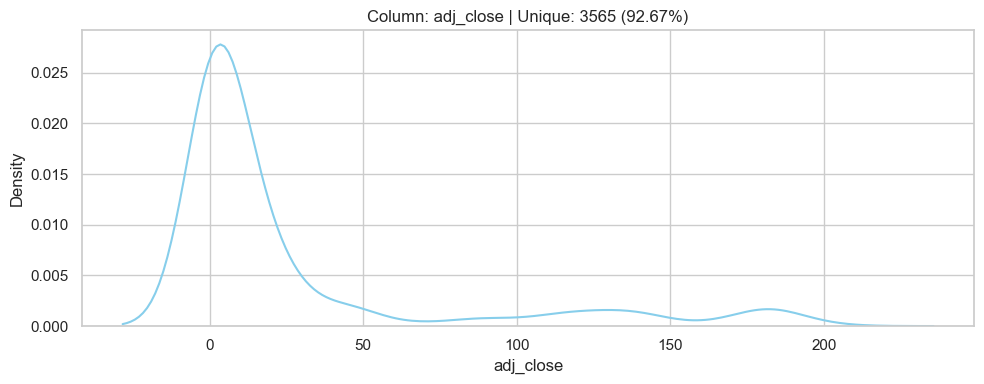

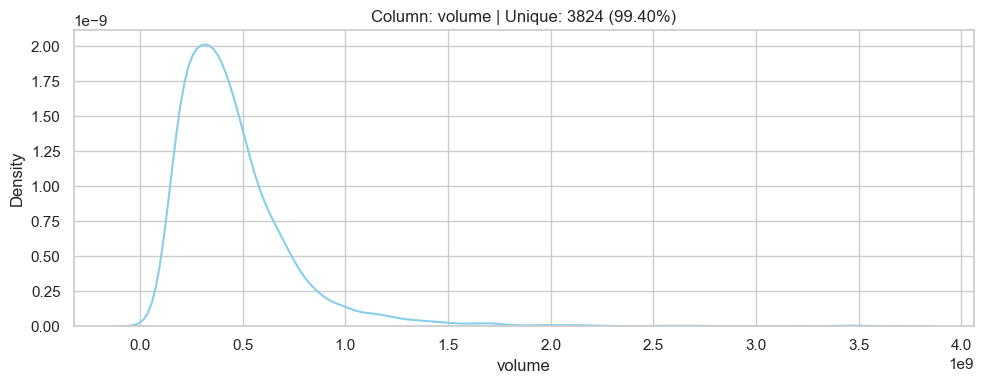

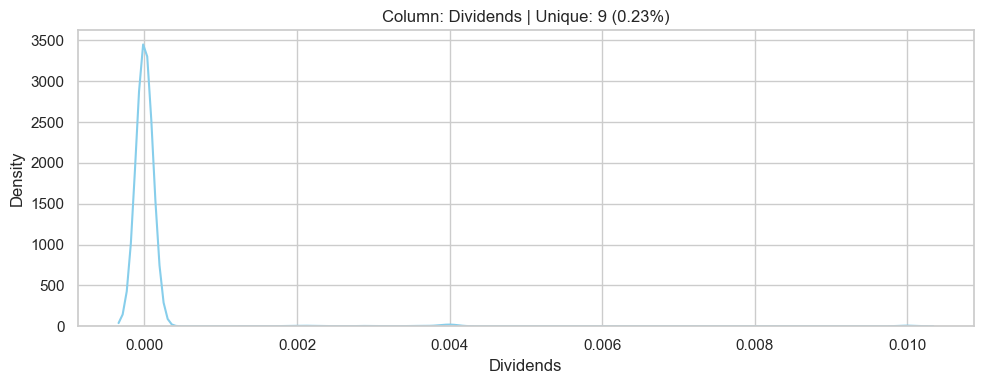

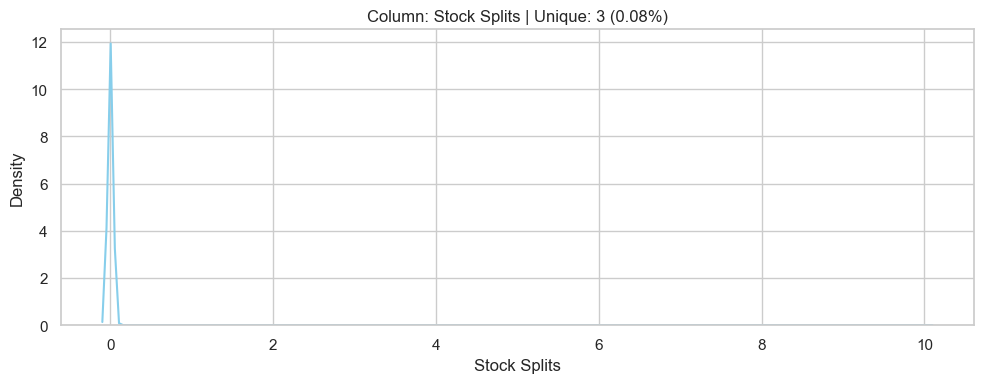

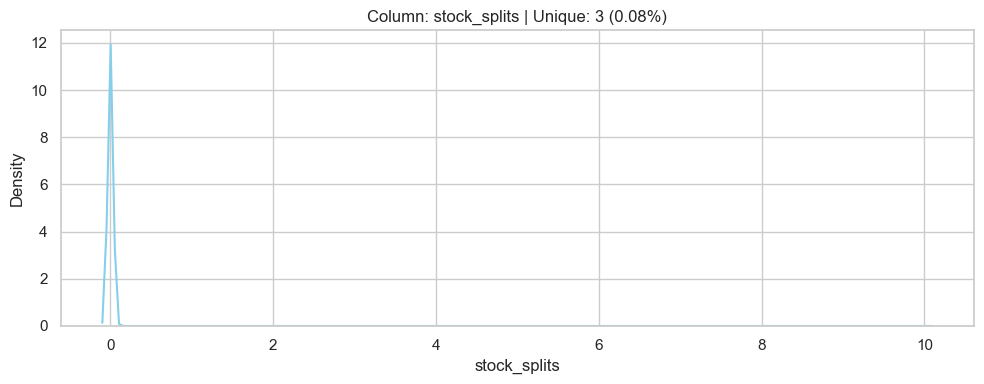

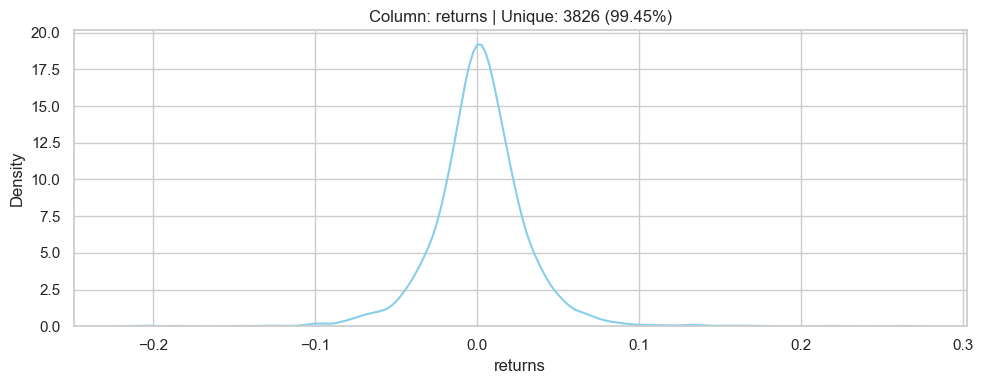

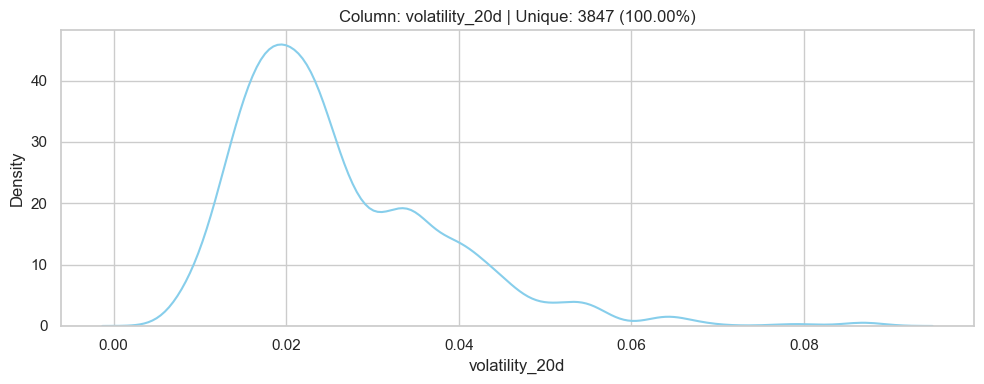

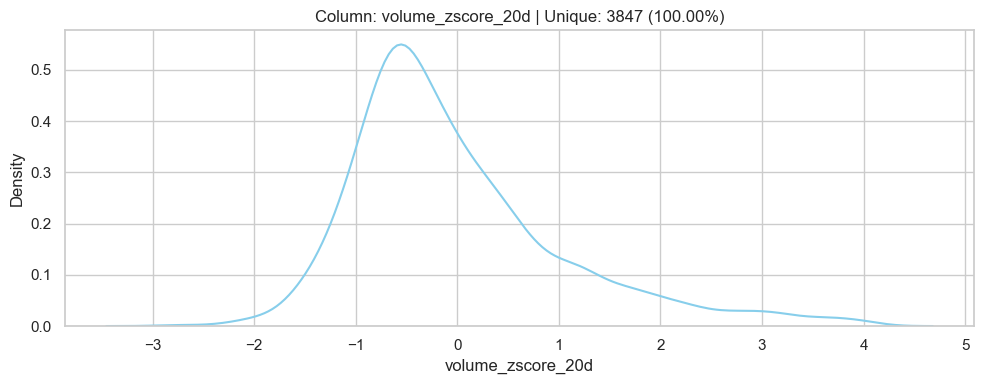

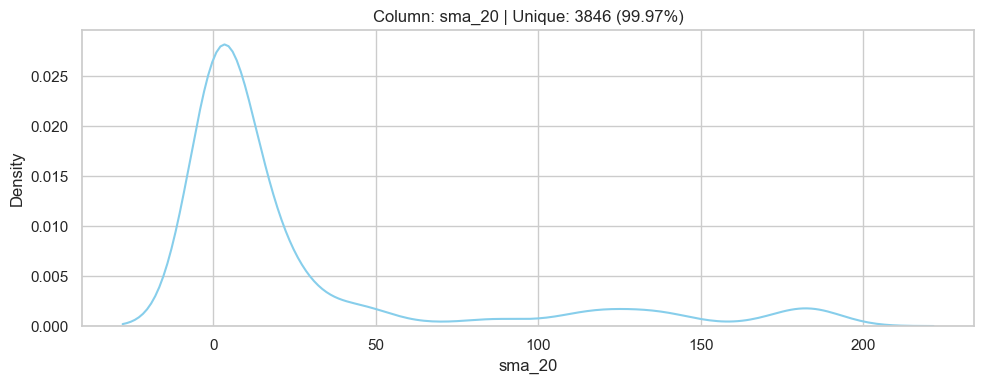

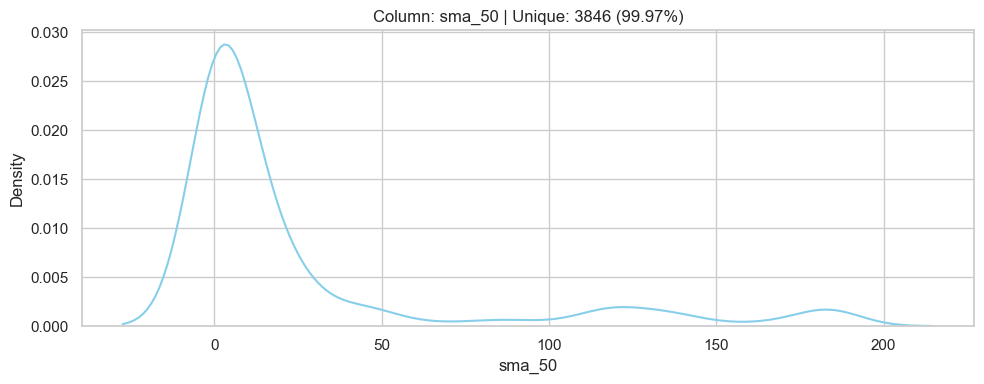

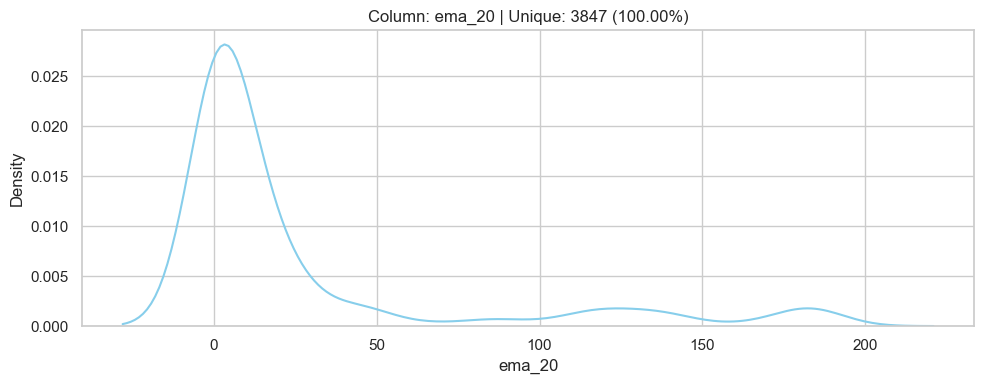

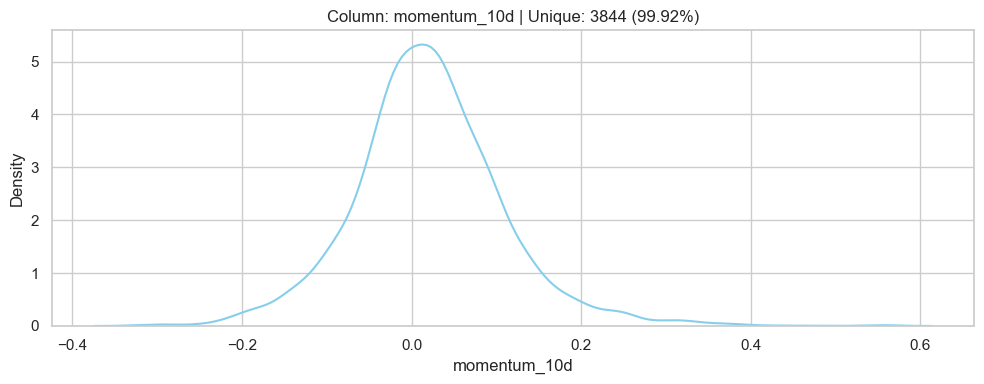

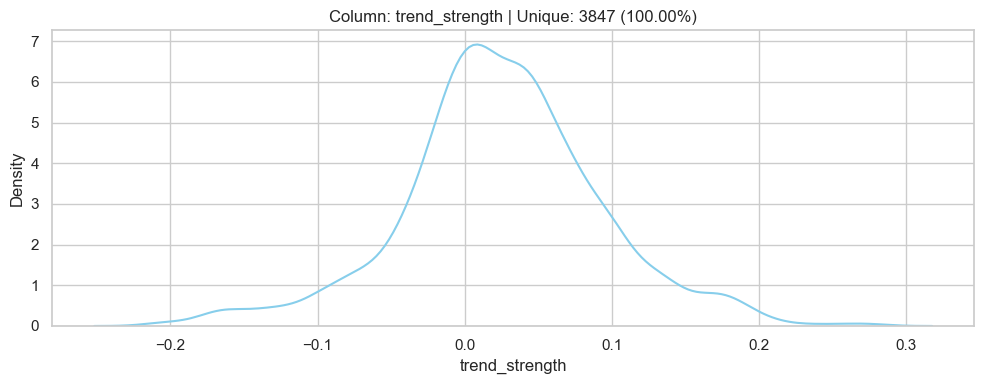

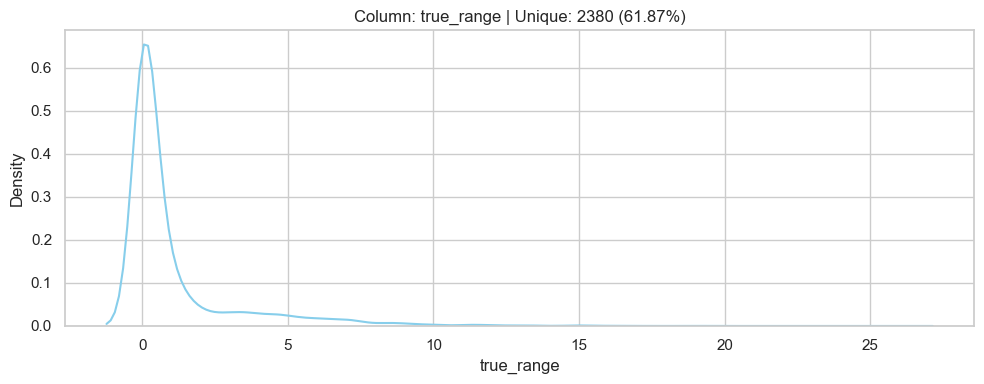

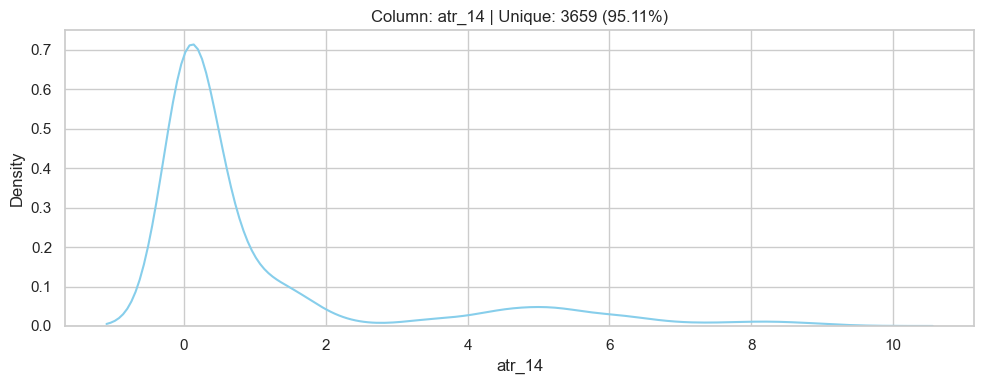

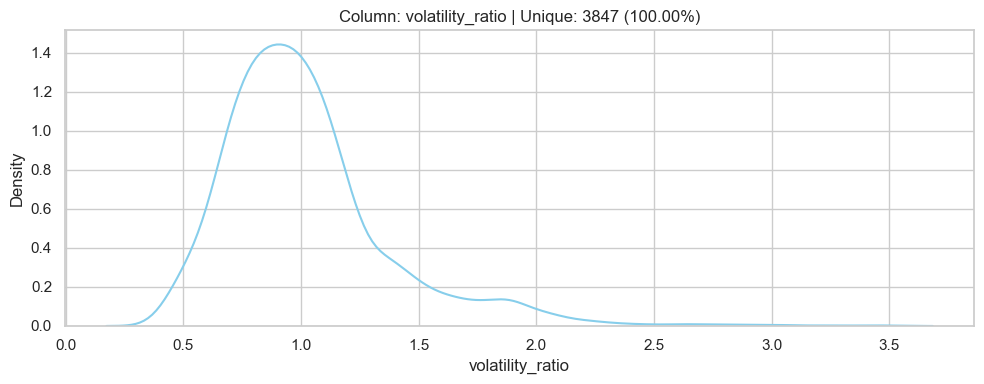

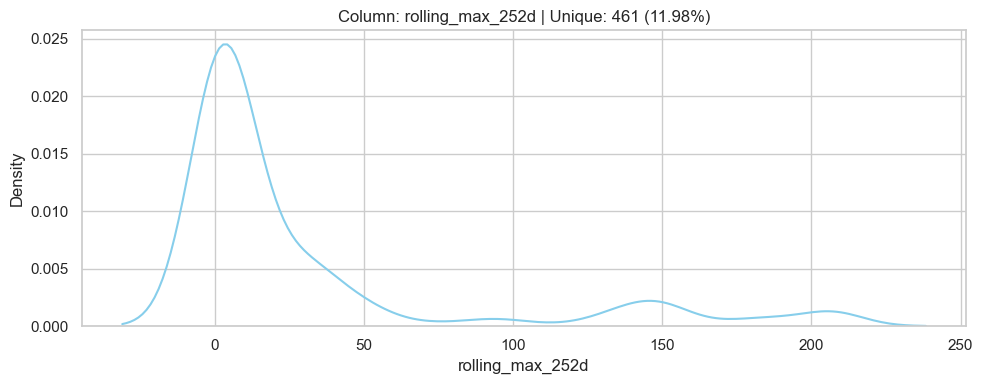

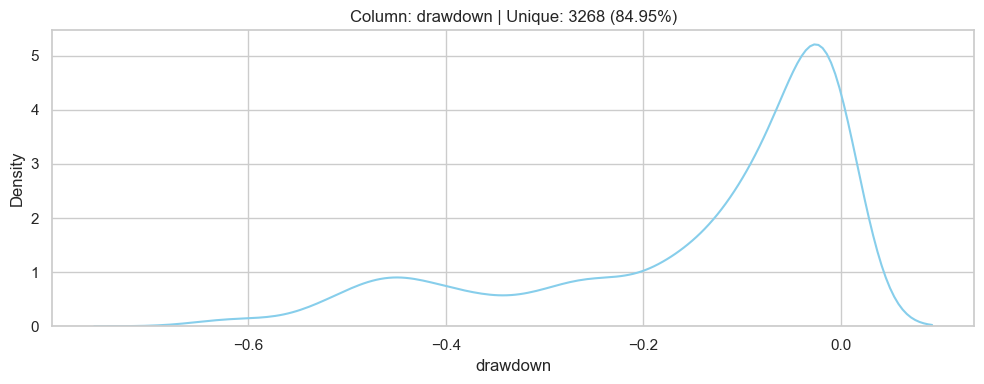

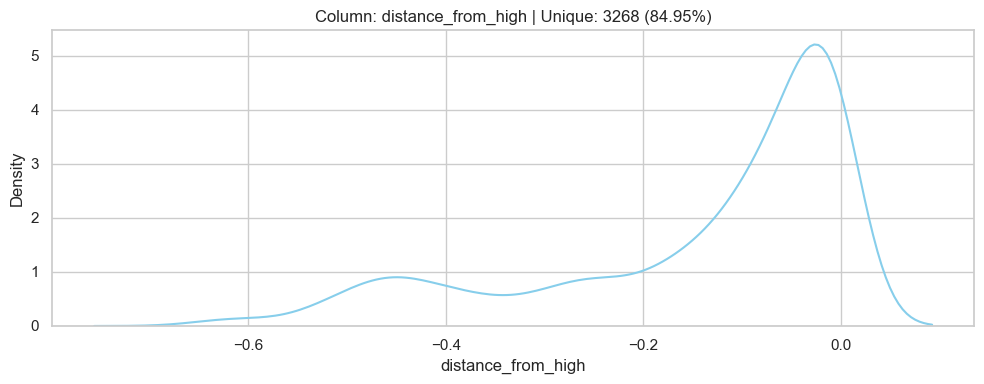

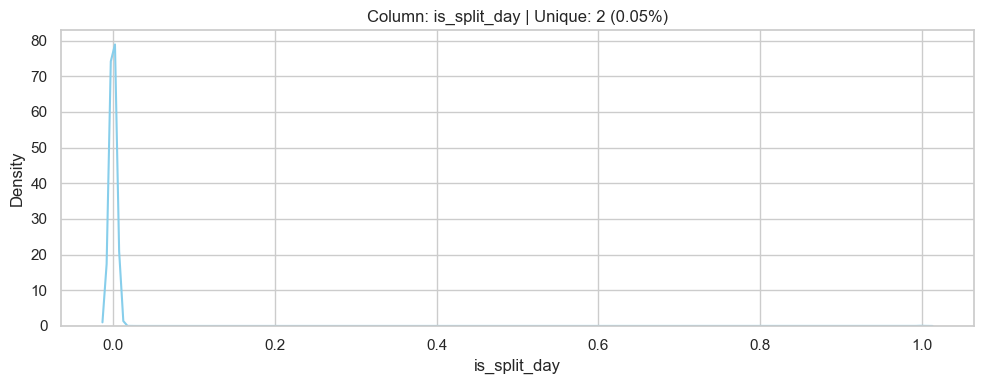

In [8]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Skipping {col}: Non-numeric data")
        continue
    unique_count = df[col].nunique()
    total_count = df[col].count()

    plt.figure(figsize=(10, 4))
    sns.kdeplot(x=df[col], color="skyblue")

    plt.title(f"Column: {col} | Unique: {unique_count} ({unique_count/total_count:.2%})")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [9]:
# Drop rows where any of these specific columns have NaN values
df = df.drop(columns=[ 'stock_splits', 'is_split_day'])

In [10]:
df.head()

,date,open,high,low,close,adj_close,volume,Dividends,Stock Splits,returns,volatility_20d,volume_zscore_20d,sma_20,sma_50,ema_20,momentum_10d,trend_strength,true_range,atr_14,volatility_ratio,rolling_max_252d,drawdown,distance_from_high
0,2010-12-31 00:00:00-05:00,0.375,0.386,0.375,0.385,0.353,391252000,0.000,0.000,0.027,0.018,-0.468,0.339,0.312,0.336,0.078,0.087,0.011,0.009,0.840,0.433,-0.184,-0.184
1,2011-01-03 00:00:00-05:00,0.388,0.399,0.387,0.396,0.363,817448000,0.000,0.000,0.027,0.018,1.232,0.340,0.314,0.338,0.101,0.083,0.014,0.009,0.842,0.433,-0.162,-0.162
2,2011-01-04 00:00:00-05:00,0.396,0.398,0.386,0.394,0.361,651384000,0.000,0.000,-0.003,0.017,0.515,0.341,0.316,0.341,0.102,0.081,0.012,0.009,0.814,0.433,-0.165,-0.165
3,2011-01-05 00:00:00-05:00,0.401,0.425,0.398,0.424,0.389,1428216000,0.000,0.000,0.074,0.022,2.933,0.344,0.318,0.345,0.142,0.080,0.031,0.010,1.074,0.425,-0.085,-0.085
4,2011-01-06 00:00:00-05:00,0.435,0.484,0.434,0.483,0.443,3493312000,0.000,0.000,0.130,0.035,3.866,0.349,0.322,0.355,0.286,0.084,0.059,0.014,1.695,0.443,0.000,0.000


In [11]:
df['date'] = df['date'].dt.date
df['volume_millions'] = df['volume'] / 1000
df["close_pct_daily_change"] = df["adj_close"].pct_change()

In [12]:
df["vol_pct_daily_change"] = df["volume"].pct_change()

# 5-day rolling volatility of volume changes
df["vol_pct_5d"] = df["vol_pct_daily_change"].rolling(5).std()

# Fix: make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month

df["up_day"] = (df["close_pct_daily_change"] > 0).astype(int)


<Axes: xlabel='volume_millions', ylabel='Density'>

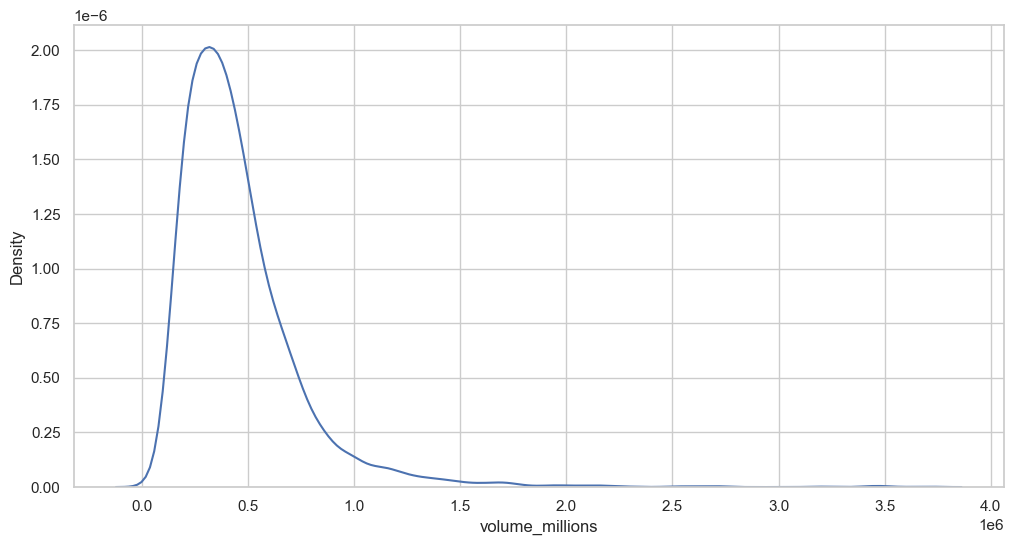

In [13]:
sns.kdeplot(df,x='volume_millions')

In [14]:
df

,date,open,high,low,close,adj_close,volume,Dividends,Stock Splits,returns,volatility_20d,volume_zscore_20d,sma_20,sma_50,ema_20,momentum_10d,trend_strength,true_range,atr_14,volatility_ratio,rolling_max_252d,drawdown,distance_from_high,volume_millions,close_pct_daily_change,vol_pct_daily_change,vol_pct_5d,day_of_month,day_of_week,week_of_year,month,up_day
0,2010-12-31,0.375,0.386,0.375,0.385,0.353,391252000,0.000,0.000,0.027,0.018,-0.468,0.339,0.312,0.336,0.078,0.087,0.011,0.009,0.840,0.433,-0.184,-0.184,391252.000,NaN,NaN,NaN,31,4,52,12,0
1,2011-01-03,0.388,0.399,0.387,0.396,0.363,817448000,0.000,0.000,0.027,0.018,1.232,0.340,0.314,0.338,0.101,0.083,0.014,0.009,0.842,0.433,-0.162,-0.162,817448.000,0.027,1.089,NaN,3,0,1,1,1
2,2011-01-04,0.396,0.398,0.386,0.394,0.361,651384000,0.000,0.000,-0.003,0.017,0.515,0.341,0.316,0.341,0.102,0.081,0.012,0.009,0.814,0.433,-0.165,-0.165,651384.000,-0.003,-0.203,NaN,4,1,1,1,0
3,2011-01-05,0.401,0.425,0.398,0.424,0.389,1428216000,0.000,0.000,0.074,0.022,2.933,0.344,0.318,0.345,0.142,0.080,0.031,0.010,1.074,0.425,-0.085,-0.085,1428216.000,0.077,1.193,NaN,5,2,1,1,1
4,2011-01-06,0.435,0.484,0.434,0.483,0.443,3493312000,0.000,0.000,0.130,0.035,3.866,0.349,0.322,0.355,0.286,0.084,0.059,0.014,1.695,0.443,0.000,0.000,3493312.000,0.138,1.446,NaN,6,3,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3842,2026-04-14,190.840,196.510,190.770,196.510,196.510,161307000,0.000,0.000,0.037,0.023,-0.126,178.538,182.116,181.699,0.190,-0.020,7.200,5.424,1.014,207.017,-0.051,-0.051,161307.000,0.038,0.207,0.251,14,1,16,4,1
3843,2026-04-15,196.540,200.400,195.740,198.870,198.870,185338400,0.000,0.000,0.012,0.023,0.592,179.385,182.382,183.334,0.140,-0.016,4.660,5.327,1.005,207.017,-0.039,-0.039,185338.400,0.012,0.149,0.253,15,2,16,4,1
3844,2026-04-16,197.430,199.850,195.810,198.350,198.350,134012900,0.000,0.000,-0.003,0.023,-0.897,180.282,182.742,184.764,0.129,-0.013,4.040,5.077,0.996,207.017,-0.042,-0.042,134012.900,-0.003,-0.277,0.272,16,3,16,4,0
3845,2026-04-17,199.900,201.700,199.270,201.680,201.680,159843200,0.000,0.000,0.017,0.023,-0.121,181.438,183.292,186.375,0.137,-0.010,3.350,5.014,0.986,207.017,-0.026,-0.026,159843.200,0.017,0.193,0.226,17,4,16,4,1


In [15]:
df.to_csv('nvidia_features.csv', index=True)

## Exploratory Analysis

Text(0.5, 1.0, 'NVIDIA Close Prices')

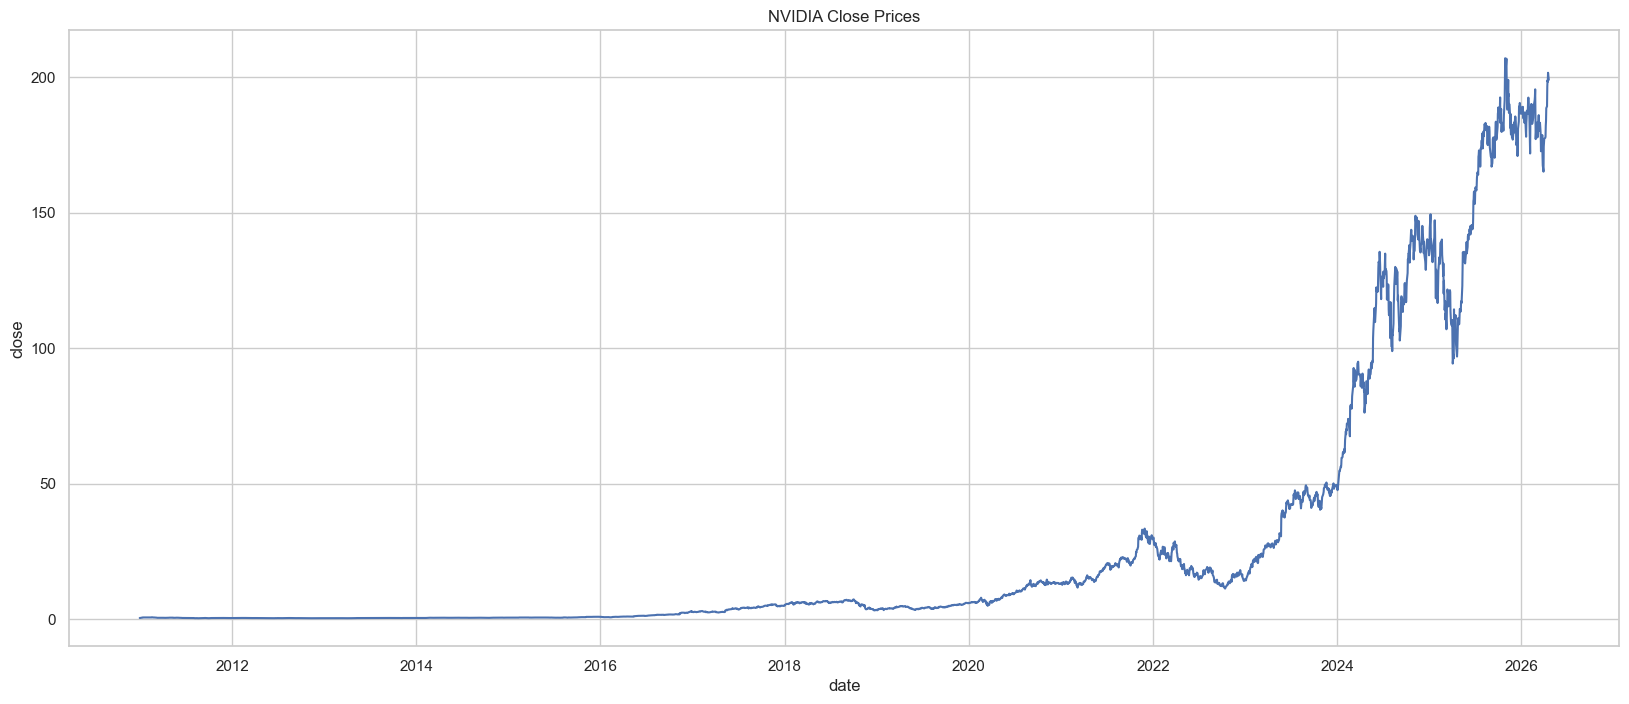

In [16]:
plt.figure(figsize=(20, 8))

sns.lineplot(data=df, x='date', y='close').set_title("NVIDIA Close Prices")

Nvidia stock has been on a prett wild ride since 2010 especially in the last couple years. Let's log the y axis so we can get a better view of the stock price trajectory

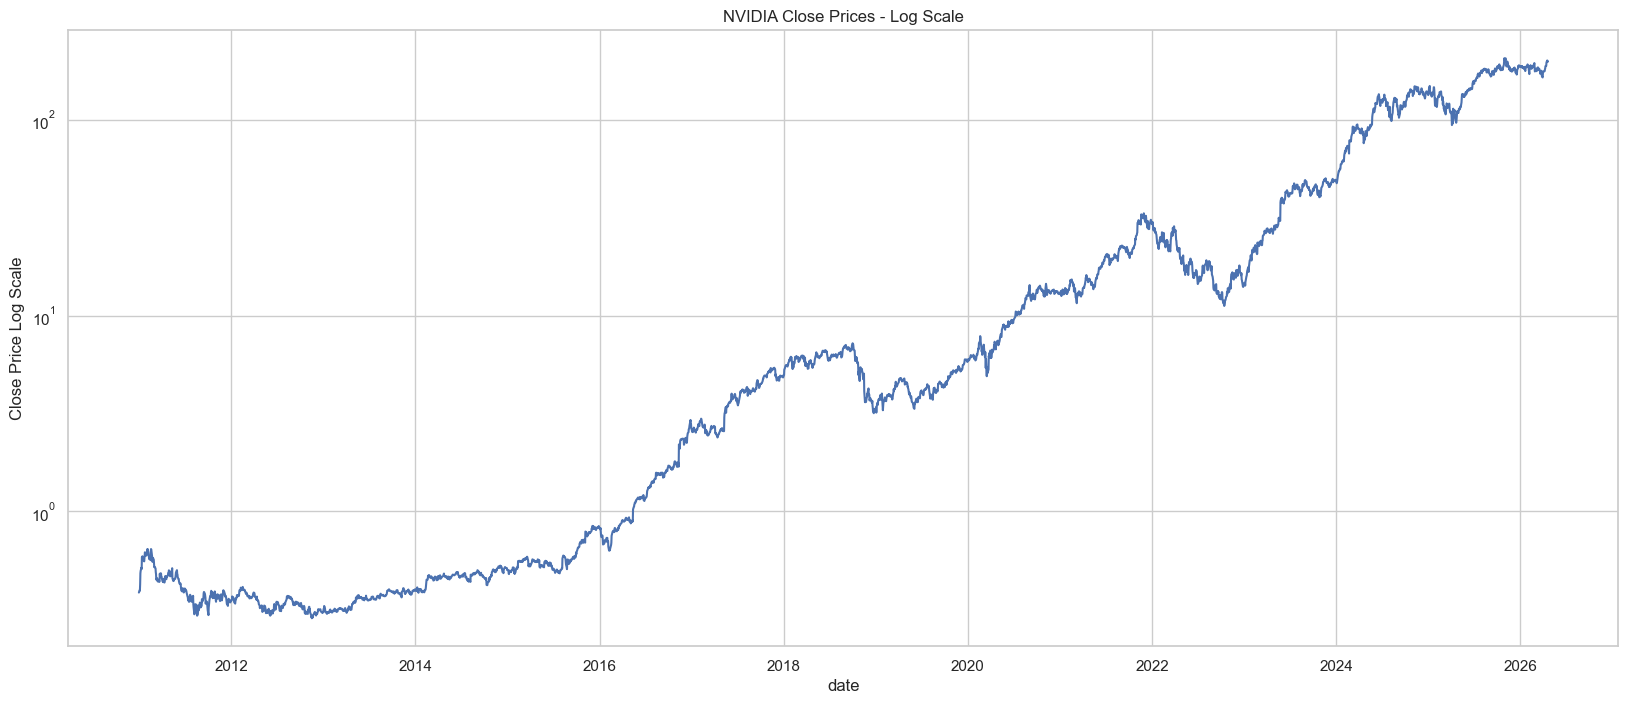

In [17]:
plt.figure(figsize=(20, 8))

ax = sns.lineplot(data=df, x='date', y='close')
ax.set_title("NVIDIA Close Prices - Log Scale")
ax.set_ylabel("Close Price Log Scale")

ax.set_yscale("log")

plt.show()

Nvidia had a couple of turning point moment where the price really exploded. Around early 2016 and 2023, these might be due to company news which we won't capture in data. For example 2023 was around the launch of Chatgpt and the beginning of AI dependence on microchips.

Let's see how that trajectory looks in as a distributions of daily returns.

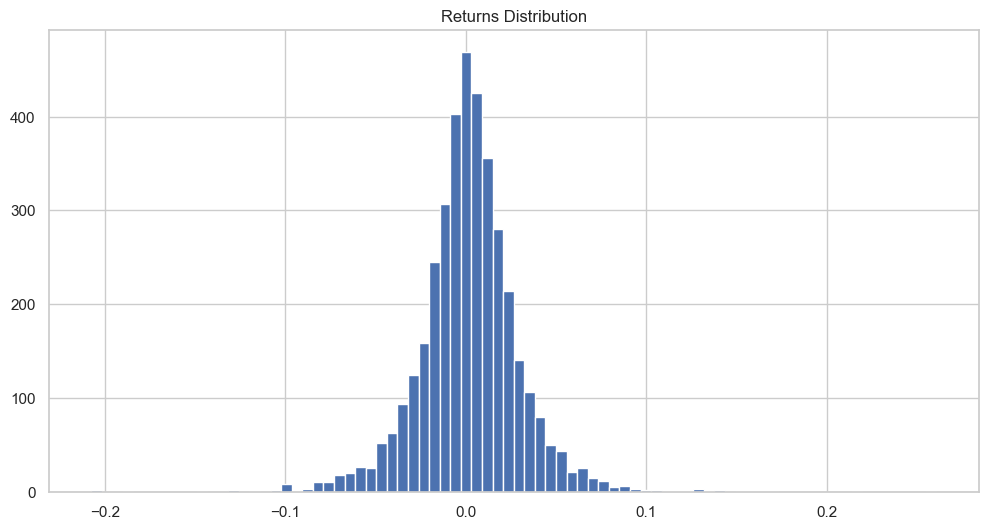

Average return: 0.17% | Median return: 0.18%


In [18]:
plt.hist(df['returns'], bins=80)
plt.title('Returns Distribution')
plt.show()

mean_val = df['returns'].mean()
median_val = df['returns'].median()

print(f"Average return: {mean_val:.2%} | Median return: {median_val:.2%}")


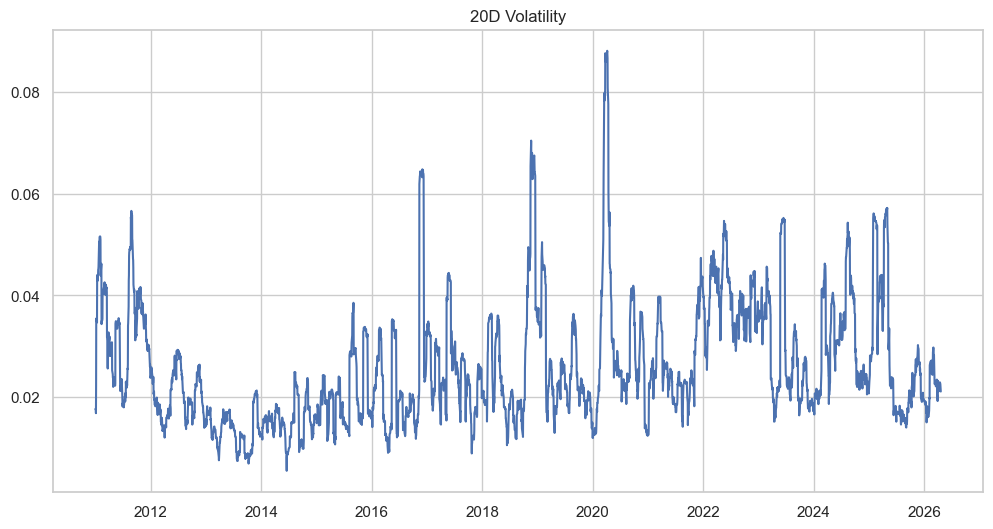

In [19]:
plt.plot(df['date'], df['volatility_20d'])
plt.title('20D Volatility')
plt.show()


Looking at the 20-day volatility chart, we can see there are some specific peaks around 2017 and 2019 but the biggest peak being around 2020 when COVID hit and the markets had a big sell-off. We aren't able to track the reasons for the volatility in the data, but we can at least use volatility as a sign of big swings in price.

<Axes: >

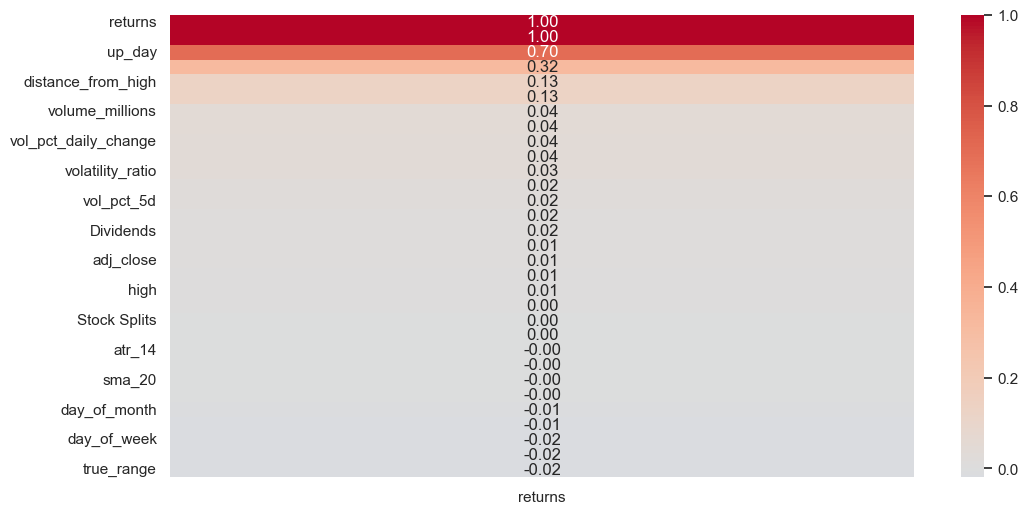

In [20]:
numeric_df = df.select_dtypes(include=[np.number])

target = "returns"

corr_target = numeric_df.corr()[["returns"]].sort_values(by=target, ascending=False)

sns.heatmap(corr_target, annot=True, fmt=".2f", cmap="coolwarm", center=0)

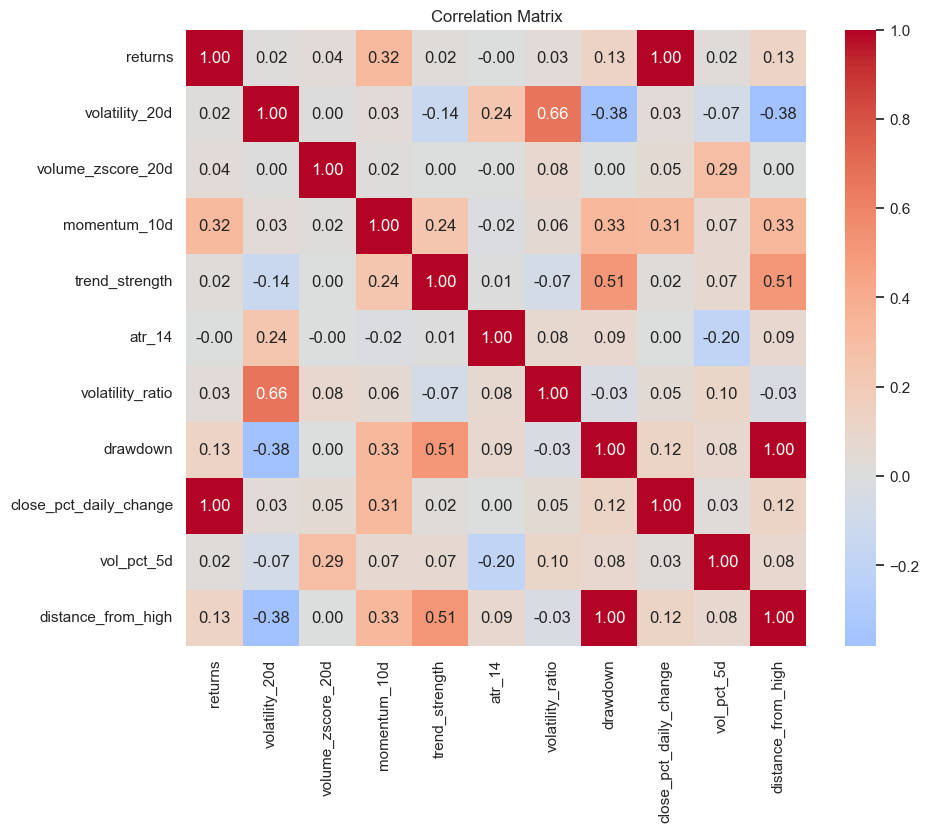

In [21]:
eda_features = [
    "returns",
    "volatility_20d",
    "volume_zscore_20d",
    "momentum_10d",
    "trend_strength",
    "atr_14",
    "volatility_ratio",
    "drawdown",
    "close_pct_daily_change",
    "vol_pct_5d",
    "distance_from_high"
]

# Calculate correlation matrix
corr = df[eda_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

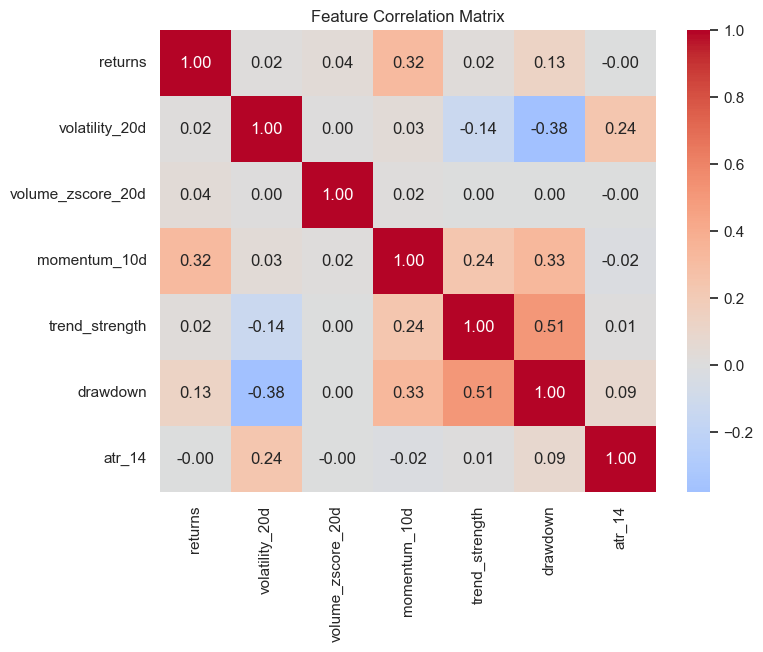

In [22]:
features = ['returns','volatility_20d','volume_zscore_20d','momentum_10d','trend_strength','drawdown','atr_14']
corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Feature Correlation Matrix')
plt.show()


Before we get stuck into the unsupervised learning, I want to check out to see if there's any bias in our training data. So for example, are certain days better than other days? This would be helpful to see if there's any, like, anything hidden inside the data that we can't see in all of these summary statistics.

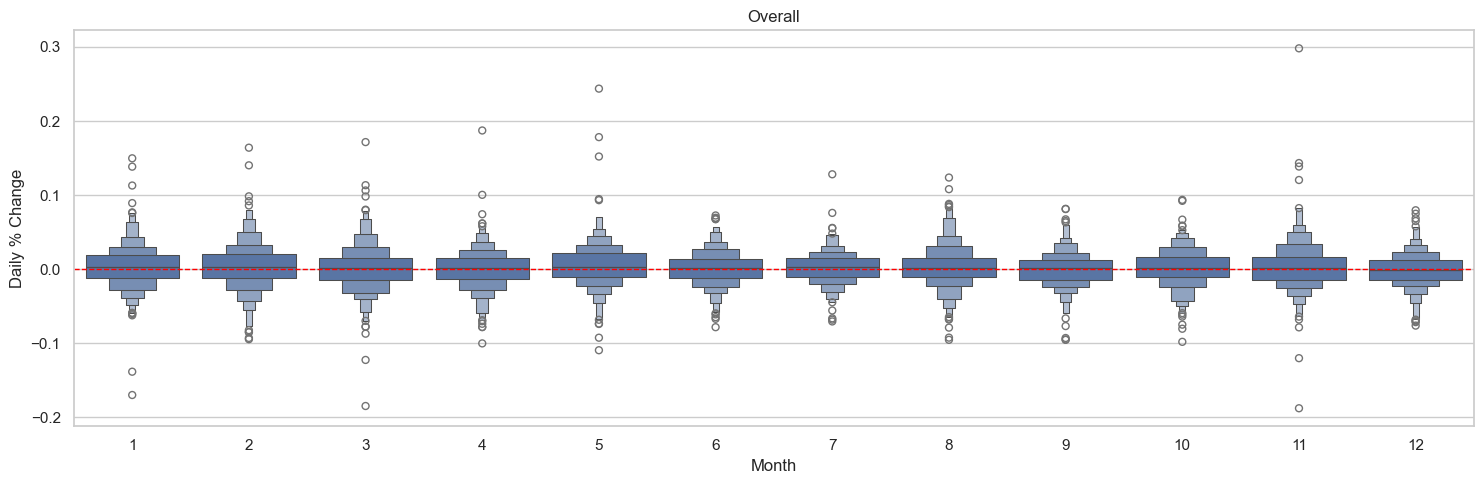

In [23]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.boxenplot(
    data=df,
    x="month",
    y="close_pct_daily_change",
    color="#4C72B0",
    ax=ax
)

ax.set_title("Overall")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Month")
ax.set_ylabel("Daily % Change")

plt.tight_layout()
plt.show()


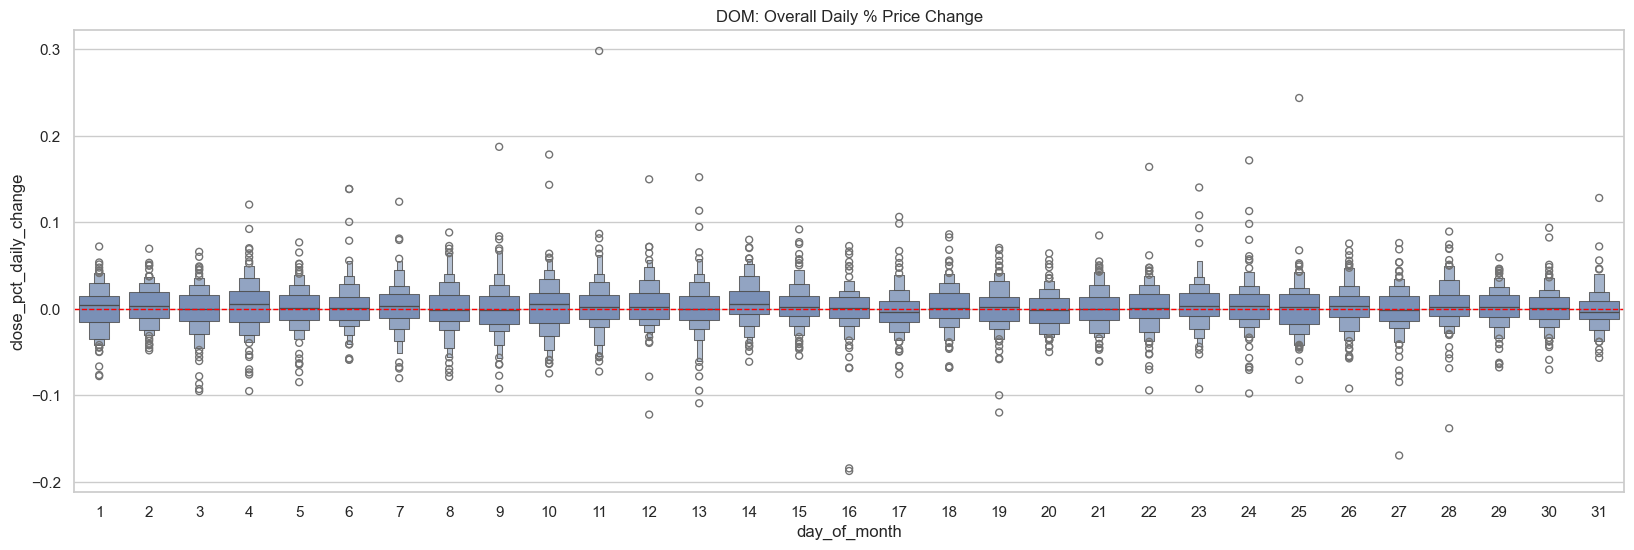

In [24]:
plt.figure(figsize=(20, 6))

ax = sns.boxenplot(
    data=df,
    x="day_of_month",
    y="close_pct_daily_change",
    color="#4C72B0",
    alpha=0.8
)

ax.set_title("DOM: Overall Daily % Price Change")
ax.axhline(0, color="red", linestyle="--", linewidth=1)

plt.show()

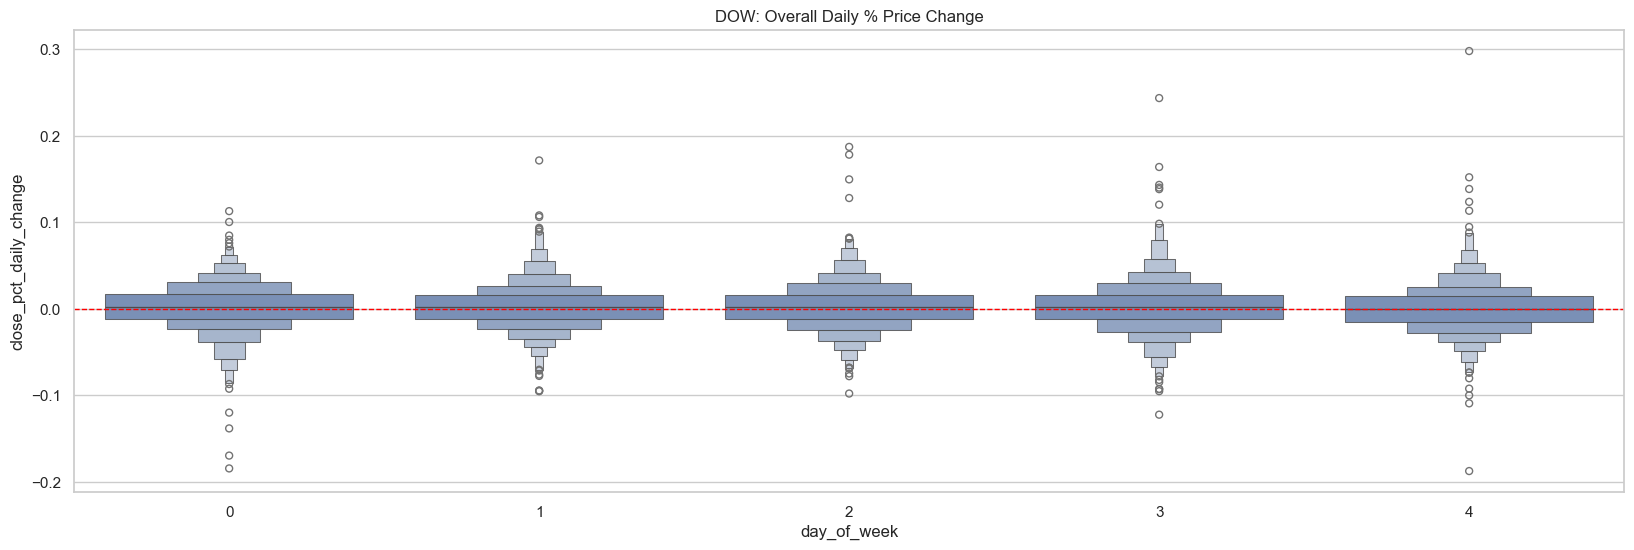

In [25]:
plt.figure(figsize=(20, 6))

ax = sns.boxenplot(
    data=df,
    x="day_of_week",
    y="close_pct_daily_change",
    color="#4C72B0",
    alpha=0.8
)

ax.set_title("DOW: Overall Daily % Price Change")
ax.axhline(0, color="red", linestyle="--", linewidth=1)

plt.show()


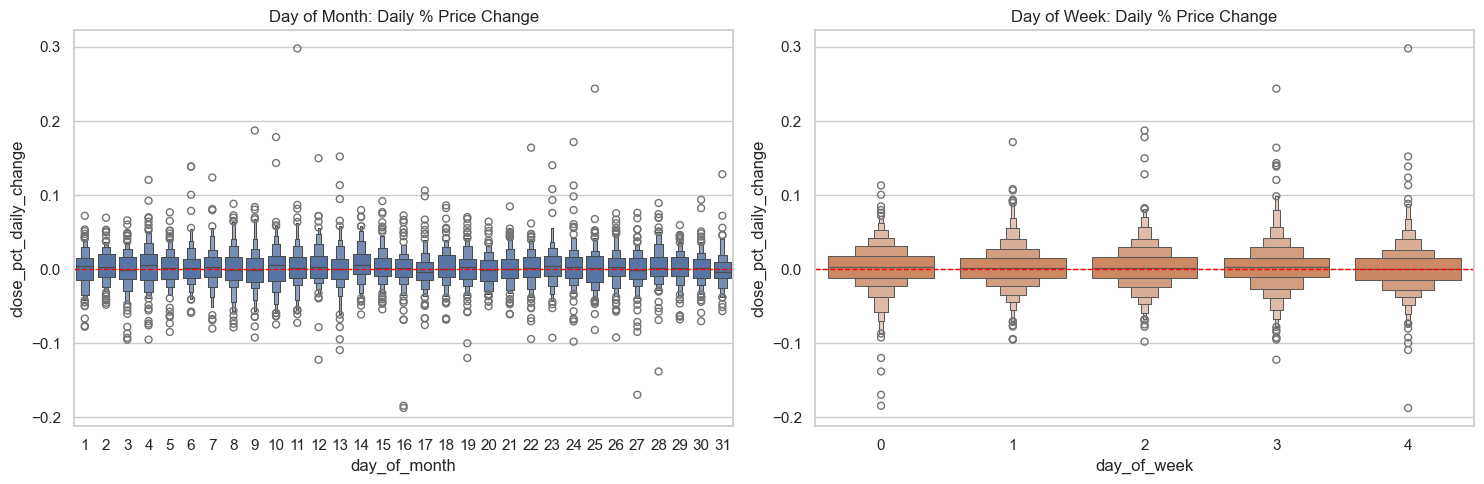

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Day of Month
sns.boxenplot(
    data=df,
    x="day_of_month",
    y="close_pct_daily_change",
    ax=ax[0],
    color="#4C72B0"
)
ax[0].set_title("Day of Month: Daily % Price Change")
ax[0].axhline(0, color="red", linestyle="--", linewidth=1)

# Day of Week
sns.boxenplot(
    data=df,
    x="day_of_week",
    y="close_pct_daily_change",
    ax=ax[1],
    color="#DD8452"
)
ax[1].set_title("Day of Week: Daily % Price Change")
ax[1].axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


Although there's some natural variation in the mins and the maximums of some days where there's like extreme events, generally speaking, everything seems to be pretty normally distributed around zero. So it doesn't seem like there's any days, months, or days of the month which favour better or worse returns.

## Unsupervised Learning

In [46]:
unsup_features = [
    "returns",            # direction & magnitude
    "momentum_10d",       # trend persistence
    "trend_strength",     # medium-term trend
    "volatility_20d",     # turbulence
    "volatility_ratio",   # volatility acceleration
    "volume_zscore_20d",  # unusual participation
    "drawdown",           # risk / stress
]

unsup_df = df[unsup_features].dropna().copy()
unsup_idx = unsup_df.index

scaler = StandardScaler()
X = scaler.fit_transform(unsup_df)

pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X)

for i in range(3):
    df.loc[unsup_idx, f"pca_{i+1}"] = X_pca[:, i]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())

Explained variance ratio: [0.28514118 0.22857486 0.14787717 0.14234437]
Cumulative explained variance: [0.28514118 0.51371604 0.66159321 0.80393758]


In [47]:
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    scores[k] = silhouette_score(X_pca, labels)

scores

{2: 0.310168571518646,
 3: 0.3063530451457331,
 4: 0.2847076657009045,
 5: 0.28511209440447355,
 6: 0.1914894344571195}

In [48]:
best_k = max(scores, key=scores.get)
print("Chosen number of regimes:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_pca)

df.loc[unsup_idx, "regime_id"] = labels
df["regime_id"] = df["regime_id"].astype("Int64")

regime_summary = (
    df.dropna(subset=["regime_id"])
      .groupby("regime_id")[["returns", "volatility_20d", "momentum_10d", "drawdown"]]
      .mean()
      .sort_values("returns")
)

regime_summary

Chosen number of regimes: 2


,returns,volatility_20d,momentum_10d,drawdown
regime_id,,,,
1,-0.004,0.037,-0.025,-0.333
0,0.004,0.022,0.038,-0.071


In [49]:
sorted_regimes = regime_summary.index.tolist()

if len(sorted_regimes) == 2:
    regime_map = {
        sorted_regimes[0]: "bearish",
        sorted_regimes[1]: "bullish"
    }
elif len(sorted_regimes) == 3:
    regime_map = {
        sorted_regimes[0]: "bearish",
        sorted_regimes[1]: "sideways",
        sorted_regimes[2]: "bullish"
    }
else:
    regime_map = {sorted_regimes[0]: "bearish", sorted_regimes[-1]: "bullish"}
    for r in sorted_regimes[1:-1]:
        regime_map[r] = "sideways"

df["regime_name"] = df["regime_id"].map(regime_map)
df[["date", "returns", "pca_1", "pca_2", "regime_id", "regime_name"]].tail()

,date,returns,pca_1,pca_2,regime_id,regime_name
3842,2026-04-14,0.037,0.929,1.219,0,bullish
3843,2026-04-15,0.012,0.683,0.714,0,bullish
3844,2026-04-16,-0.003,0.613,0.293,0,bullish
3845,2026-04-17,0.017,0.827,0.678,0,bullish
3846,2026-04-20,-0.013,0.762,-0.223,0,bullish


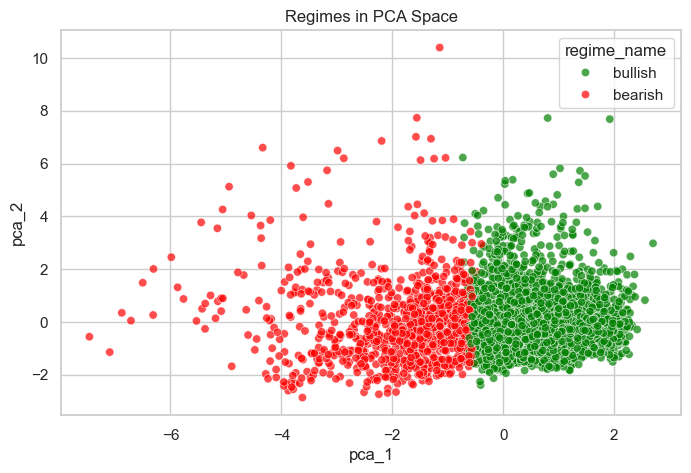

In [50]:
plt.figure(figsize=(8, 5))

palette = {
    "bearish": "red",
    "bullish": "green",
    "sideways": "grey"
}

sns.scatterplot(
    data=df.dropna(subset=["pca_1", "pca_2", "regime_name"]),
    x="pca_1",
    y="pca_2",
    hue="regime_name",
    palette=palette,
    alpha=0.7
)
plt.title("Regimes in PCA Space")
plt.show()

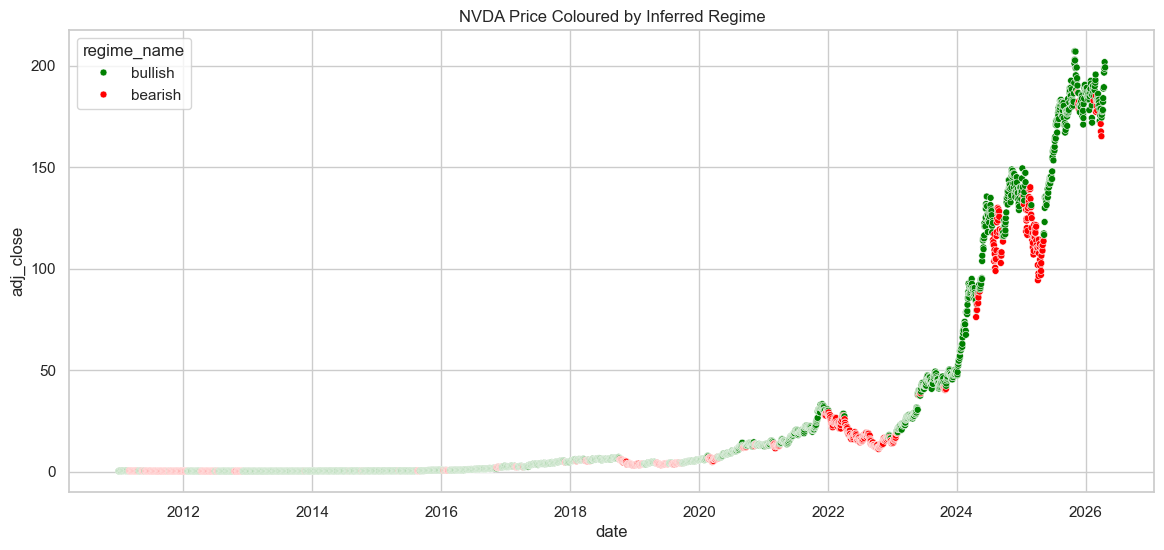

In [51]:
plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df.dropna(subset=["regime_name"]),
    x="date",
    y="adj_close",
    hue="regime_name",
    palette=palette,
    s=25
)

plt.title("NVDA Price Coloured by Inferred Regime")
plt.show()

## Reinforcement Learning

In [52]:
rl_df = df.dropna(subset=[
    "regime_id", "trend_strength", "volatility_ratio",
    "momentum_10d", "close_pct_daily_change", "date"
]).copy()

# Chronological split
n = len(rl_df)
train_end = int(n * 0.70)
test_start = int(n * 0.85)

train_df = rl_df.iloc[:train_end].copy()
test_df = rl_df.iloc[test_start:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (2692, 37)
Test shape: (577, 37)


In [53]:
# Fit bins on the training set only
trend_bins = np.quantile(train_df["trend_strength"], [0, 0.33, 0.66, 1.0])
vol_bins = np.quantile(train_df["volatility_ratio"], [0, 0.33, 0.66, 1.0])
mom_bins = np.quantile(train_df["momentum_10d"], [0, 0.33, 0.66, 1.0])


train_df["trend_bucket"] = train_df["trend_strength"].apply(lambda x: hf.safe_digitize(x, trend_bins))
train_df["vol_bucket"] = train_df["volatility_ratio"].apply(lambda x: hf.safe_digitize(x, vol_bins))
train_df["mom_bucket"] = train_df["momentum_10d"].apply(lambda x: hf.safe_digitize(x, mom_bins))

test_df["trend_bucket"] = test_df["trend_strength"].apply(lambda x: hf.safe_digitize(x, trend_bins))
test_df["vol_bucket"] = test_df["volatility_ratio"].apply(lambda x: hf.safe_digitize(x, vol_bins))
test_df["mom_bucket"] = test_df["momentum_10d"].apply(lambda x: hf.safe_digitize(x, mom_bins))

train_df[["trend_strength", "trend_bucket", "volatility_ratio", "vol_bucket", "momentum_10d", "mom_bucket"]].head()

,trend_strength,trend_bucket,volatility_ratio,vol_bucket,momentum_10d,mom_bucket
1,0.083,2,0.842,1,0.101,2
2,0.081,2,0.814,0,0.102,2
3,0.080,2,1.074,2,0.142,2
4,0.084,2,1.695,2,0.286,2
5,0.090,2,1.656,2,0.332,2


### Trading Enviroement

In [54]:
ACTION_TO_POSITION = {0: -1, 1: 0, 2: 1}
POSITION_TO_STATE = {-1: 0, 0: 1, 1: 2}

In [55]:
q_table, episode_rewards = hf.train_q_learning(
    data=train_df,
    POSITION_TO_STATE=POSITION_TO_STATE,
    ACTION_TO_POSITION=ACTION_TO_POSITION,
    n_episodes=300
)

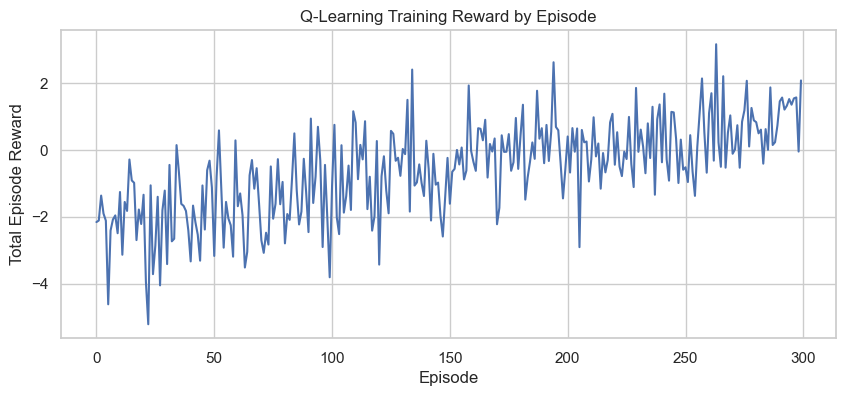

In [56]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.title("Q-Learning Training Reward by Episode")
plt.xlabel("Episode")
plt.ylabel("Total Episode Reward")
plt.show()

### What if we built an ensemble based in multiple agent runs?

Training one Q-learning agent is noisy because it explores randomly during training, two runs with different seeds can end up with very different strategies. The ensemble trains 5 agents instead and has them vote on every trade: each agent scores the three actions (short/flat/long), you sum the scores across all 5, and pick whichever action wins.

Confident agents sway the vote more than uncertain ones, and because each agent's random mistakes are different, they tend to cancel out while shared signal reinforces — so the combined policy is steadier than any single agent.

In [57]:
N_SEEDS = 5

q_tables = []
for seed in range(N_SEEDS):
    np.random.seed(seed)  # controls the epsilon-greedy random choices inside train_q_learning
    q_table_s, _ = hf.train_q_learning(train_df, n_episodes=300, POSITION_TO_STATE=POSITION_TO_STATE, ACTION_TO_POSITION=ACTION_TO_POSITION)
    q_tables.append(q_table_s)

print(f"Trained {len(q_tables)} agents, state-space sizes: {[len(q) for q in q_tables]}")

Trained 5 agents, state-space sizes: [150, 150, 150, 150, 150]


In [58]:
def run_ensemble_policy(data, q_tables, transaction_cost=0.001):
    rows = []
    current_position = 0
    portfolio_value = 1.0

    for t in range(len(data) - 1):
        row = data.iloc[t]
        state = hf.get_state(row, current_position, POSITION_TO_STATE=POSITION_TO_STATE)

        # Sum Q-values across every agent that has seen this state
        votes = np.zeros(3)
        n_seen = 0
        for q in q_tables:
            if state in q:
                votes += q[state]
                n_seen += 1

        action = int(np.argmax(votes)) if n_seen > 0 else 1  # flat if no agent has seen it

        new_position = ACTION_TO_POSITION[action]
        market_return = data.iloc[t + 1]["close_pct_daily_change"]
        strategy_return = (new_position * market_return) - transaction_cost * abs(new_position - current_position)

        portfolio_value *= (1 + strategy_return)

        rows.append({
            "date": data.iloc[t + 1]["date"],
            "action": action,
            "position": new_position,
            "market_return": market_return,
            "strategy_return": strategy_return,
            "portfolio_value": portfolio_value,
            "regime_name": data.iloc[t + 1]["regime_name"],
        })
        current_position = new_position

    return pd.DataFrame(rows)


# Evaluate each seed's agent on the test set, plus the ensemble
#
per_seed_results = [
    hf.run_policy(
        test_df.reset_index(drop=True),
        q,
        POSITION_TO_STATE=POSITION_TO_STATE,
        ACTION_TO_POSITION=ACTION_TO_POSITION
    )
    for q in q_tables
]
ensemble_results   = run_ensemble_policy(test_df.reset_index(drop=True), q_tables)

# `test_results` was defined above using the original single `q_table`; leave it in place
# so the existing `test_results.head()` output still works.
print("Per-seed final portfolio values:",
       [f"{r['portfolio_value'].iloc[-1]:.3f}" for r in per_seed_results])
print(f"Ensemble final portfolio value:   {ensemble_results['portfolio_value'].iloc[-1]:.3f}")

Per-seed final portfolio values: ['0.895', '0.667', '0.985', '0.656', '0.852']
Ensemble final portfolio value:   1.056


### Evaluate Policy

In [59]:
test_results = hf.run_policy(test_df.reset_index(drop=True), q_table, POSITION_TO_STATE=POSITION_TO_STATE, ACTION_TO_POSITION=ACTION_TO_POSITION)
test_results.head()

,date,action,position,market_return,strategy_return,portfolio_value,regime_name
0,2024-01-02,2,1,-0.027,-0.028,0.972,bullish
1,2024-01-03,1,0,-0.012,-0.001,0.971,bullish
2,2024-01-04,1,0,0.009,0.000,0.971,bullish
3,2024-01-05,2,1,0.023,0.022,0.992,bullish
4,2024-01-08,1,0,0.064,-0.001,0.991,bullish


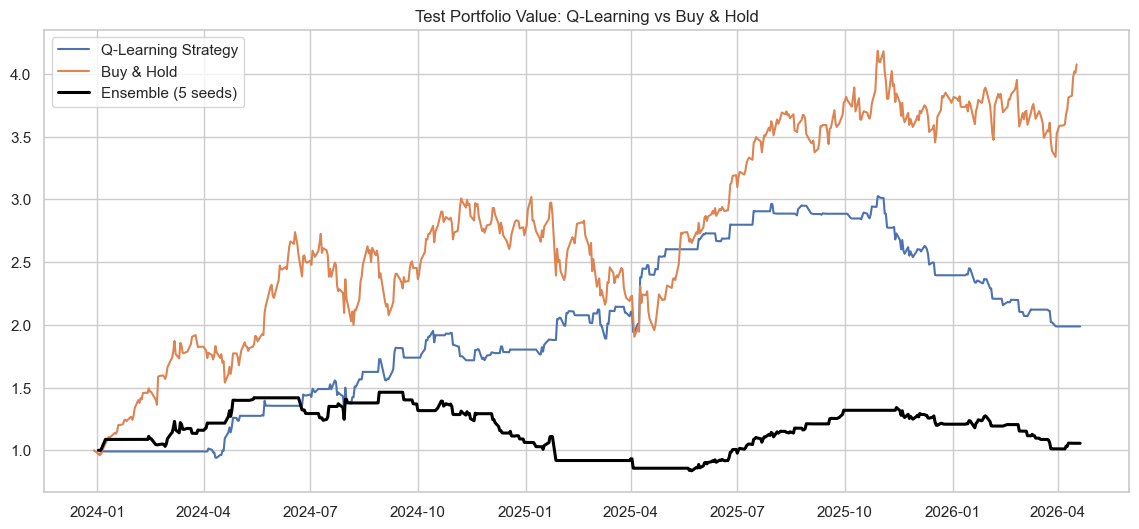

In [60]:
benchmark = test_df[["date", "close_pct_daily_change"]].copy().reset_index(drop=True)
benchmark["buy_hold_portfolio"] = (1 + benchmark["close_pct_daily_change"]).cumprod()

plot_len = min(len(test_results), len(benchmark))
plot_results = test_results.iloc[:plot_len].copy()
plot_benchmark = benchmark.iloc[:plot_len].copy()
plot_ensemble  = ensemble_results.iloc[:plot_len].copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_results["date"], plot_results["portfolio_value"], label="Q-Learning Strategy")
plt.plot(plot_benchmark["date"], plot_benchmark["buy_hold_portfolio"], label="Buy & Hold")
plt.plot(plot_ensemble["date"], plot_ensemble["portfolio_value"],label="Ensemble (5 seeds)", linewidth=2.2, color="black")
plt.title("Test Portfolio Value: Q-Learning vs Buy & Hold")
plt.legend()
plt.show()

In [61]:
plot_ensemble

,date,action,position,market_return,strategy_return,portfolio_value,regime_name
0,2024-01-02,1,0,-0.027,-0.000,1.000,bullish
1,2024-01-03,1,0,-0.012,-0.000,1.000,bullish
2,2024-01-04,1,0,0.009,0.000,1.000,bullish
3,2024-01-05,2,1,0.023,0.022,1.022,bullish
4,2024-01-08,2,1,0.064,0.064,1.088,bullish
...,...,...,...,...,...,...,...
571,2026-04-14,1,0,0.038,0.000,1.056,bullish
572,2026-04-15,1,0,0.012,0.000,1.056,bullish
573,2026-04-16,1,0,-0.003,-0.000,1.056,bullish
574,2026-04-17,1,0,0.017,0.000,1.056,bullish


In [62]:
strategy_metrics = {
    "total_return": plot_results["portfolio_value"].iloc[-1] - 1,
    "annualised_sharpe": hf.sharpe_ratio(plot_results["strategy_return"]),
    "max_drawdown": hf.max_drawdown(plot_results["portfolio_value"])
}

benchmark_metrics = {
    "total_return": plot_benchmark["buy_hold_portfolio"].iloc[-1] - 1,
    "annualised_sharpe": hf.sharpe_ratio(plot_benchmark["close_pct_daily_change"]),
    "max_drawdown": hf.max_drawdown(plot_benchmark["buy_hold_portfolio"])
}

ensemble_metrics = {
    "total_return": plot_ensemble["portfolio_value"].iloc[-1] - 1,
    "annualised_sharpe": hf.sharpe_ratio(plot_ensemble["strategy_return"]),
    "max_drawdown": hf.max_drawdown(plot_ensemble["portfolio_value"])
}

pd.DataFrame([strategy_metrics, benchmark_metrics,ensemble_metrics], index=["Q-Learning", "Buy & Hold","Ensemble"])

,total_return,annualised_sharpe,max_drawdown
Q-Learning,0.987,1.090,-0.343
Buy & Hold,3.075,1.493,-0.369
Ensemble,0.056,0.227,-0.428


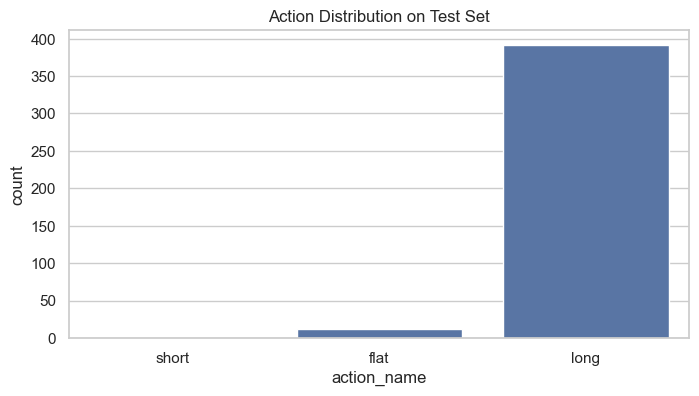

In [63]:
action_map = {-1: "short", 0: "flat", 1: "long"}
test_results["action_name"] = test_results["action"].map(action_map)

plt.figure(figsize=(8, 4))
sns.countplot(data=test_results, x="action_name", order=["short", "flat", "long"])
plt.title("Action Distribution on Test Set")
plt.show()

In [64]:
regime_action = pd.crosstab(test_results["regime_name"], test_results["action_name"], normalize="index")
regime_action

action_name,flat,long
regime_name,,
bearish,0.054,0.946
bullish,0.024,0.976
